In [9]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Cell 2: Load with ALL columns (don't drop category this time) ─────────────
df = pd.read_csv('fake reviews dataset.csv')
df.rename(columns={'text_': 'text'}, inplace=True)
df.drop_duplicates(inplace=True)

# Clean up category names (strip the trailing _5 etc.)
df['category_clean'] = df['category'].str.replace(r'_\d+$', '', regex=True)

print(df['category_clean'].value_counts())
print(df['label'].value_counts())

category_clean
Kindle_Store                  4728
Books                         4369
Pet_Supplies                  4251
Home_and_Kitchen              4056
Electronics                   3988
Sports_and_Outdoors           3944
Tools_and_Home_Improvement    3858
Clothing_Shoes_and_Jewelry    3847
Toys_and_Games                3792
Movies_and_TV                 3587
Name: count, dtype: int64
label
OR    20215
CG    20205
Name: count, dtype: int64


In [10]:
# ── Cell 3: Core feature engineering ─────────────────────────────────────────
# 1. Sentiment score from review text
df['sentiment'] = df['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# 2. Purchase proxy — rating >= 4 = "likely purchased / satisfied"
df['purchase_proxy'] = (df['rating'] >= 4).astype(int)

# 3. is_fake flag
df['is_fake'] = (df['label'] == 'CG').astype(int)

# 4. Rating-sentiment mismatch: fake reviews often have high rating but neutral/low sentiment
df['rating_sentiment_gap'] = df['rating'] - (df['sentiment'] * 5)

df[['rating', 'label', 'sentiment', 'purchase_proxy', 'rating_sentiment_gap']].head(10)

,rating,label,sentiment,purchase_proxy,rating_sentiment_gap
0,5.0,CG,0.473750,1,2.631250
1,5.0,CG,0.558333,1,2.208333
2,5.0,CG,0.250000,1,3.750000
3,1.0,CG,0.400000,0,-1.000000
4,5.0,CG,0.740000,1,1.300000
5,3.0,CG,0.000000,0,3.000000
6,5.0,CG,0.328125,1,3.359375
7,3.0,CG,0.425000,0,0.875000
8,5.0,CG,0.308333,1,3.458333
9,5.0,CG,0.200000,1,4.000000


In [11]:
# ── Cell 4: Category-level aggregations ──────────────────────────────────────
cat_stats = df.groupby('category_clean').agg(
    total_reviews       = ('label', 'count'),
    fake_count          = ('is_fake', 'sum'),
    fake_ratio          = ('is_fake', 'mean'),
    avg_rating_all      = ('rating', 'mean'),
    avg_rating_fake     = ('rating', lambda x: x[df.loc[x.index, 'is_fake'] == 1].mean()),
    avg_rating_real     = ('rating', lambda x: x[df.loc[x.index, 'is_fake'] == 0].mean()),
    avg_sentiment_fake  = ('sentiment', lambda x: x[df.loc[x.index, 'is_fake'] == 1].mean()),
    avg_sentiment_real  = ('sentiment', lambda x: x[df.loc[x.index, 'is_fake'] == 0].mean()),
    purchase_rate       = ('purchase_proxy', 'mean'),
).reset_index()

# Rating inflation = how much fake reviews inflate the avg rating
cat_stats['rating_inflation'] = cat_stats['avg_rating_fake'] - cat_stats['avg_rating_real']

# Trust erosion score (0-1): combines fake ratio + rating inflation
cat_stats['trust_erosion_score'] = (
    cat_stats['fake_ratio'] * 0.6 +
    (cat_stats['rating_inflation'].clip(0) / 5) * 0.4
).round(3)

print(cat_stats[['category_clean', 'fake_ratio', 'rating_inflation', 'trust_erosion_score']]
      .sort_values('trust_erosion_score', ascending=False))

               category_clean  fake_ratio  rating_inflation  \
5               Movies_and_TV    0.499861          0.047476   
2                 Electronics    0.500000          0.035105   
9              Toys_and_Games    0.499736          0.027261   
1  Clothing_Shoes_and_Jewelry    0.499870          0.022965   
7         Sports_and_Outdoors    0.499746          0.027704   
6                Pet_Supplies    0.499882          0.013742   
3            Home_and_Kitchen    0.500000          0.015286   
0                       Books    0.499886         -0.069465   
4                Kindle_Store    0.499788         -0.038178   
8  Tools_and_Home_Improvement    0.500000          0.001555   

   trust_erosion_score  
5                0.304  
2                0.303  
9                0.302  
1                0.302  
7                0.302  
6                0.301  
3                0.301  
0                0.300  
4                0.300  
8                0.300  


In [12]:
# ── Cell 5: Statistical test — does fake_ratio predict higher ratings? ────────
# Pearson correlation: fake ratio vs average rating per category
corr, pval = stats.pearsonr(cat_stats['fake_ratio'], cat_stats['avg_rating_all'])
print(f"Correlation (fake_ratio vs avg_rating): {corr:.3f}, p-value: {pval:.4f}")

# Also: are fake review ratings significantly higher than real ones?
fake_ratings = df[df['is_fake'] == 1]['rating']
real_ratings = df[df['is_fake'] == 0]['rating']
t_stat, p_val = stats.ttest_ind(fake_ratings, real_ratings)
print(f"\nFake avg rating: {fake_ratings.mean():.2f}")
print(f"Real avg rating: {real_ratings.mean():.2f}")
print(f"T-test p-value: {p_val:.6f}")

Correlation (fake_ratio vs avg_rating): -0.481, p-value: 0.1593

Fake avg rating: 4.26
Real avg rating: 4.25
T-test p-value: 0.582282


In [13]:
# ── Cell 6: Logistic regression — what drives purchase_proxy? ────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

features = ['rating', 'is_fake', 'sentiment', 'rating_sentiment_gap']
X = df[features].dropna()
y = df.loc[X.index, 'purchase_proxy']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression()
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

print(coef_df)
# This tells you: after controlling for other factors, how much does is_fake
# (vs is_real) actually shift the purchase likelihood?

                feature  coefficient
0                rating    10.087734
3  rating_sentiment_gap     4.921481
2             sentiment     4.051197
1               is_fake     0.028655


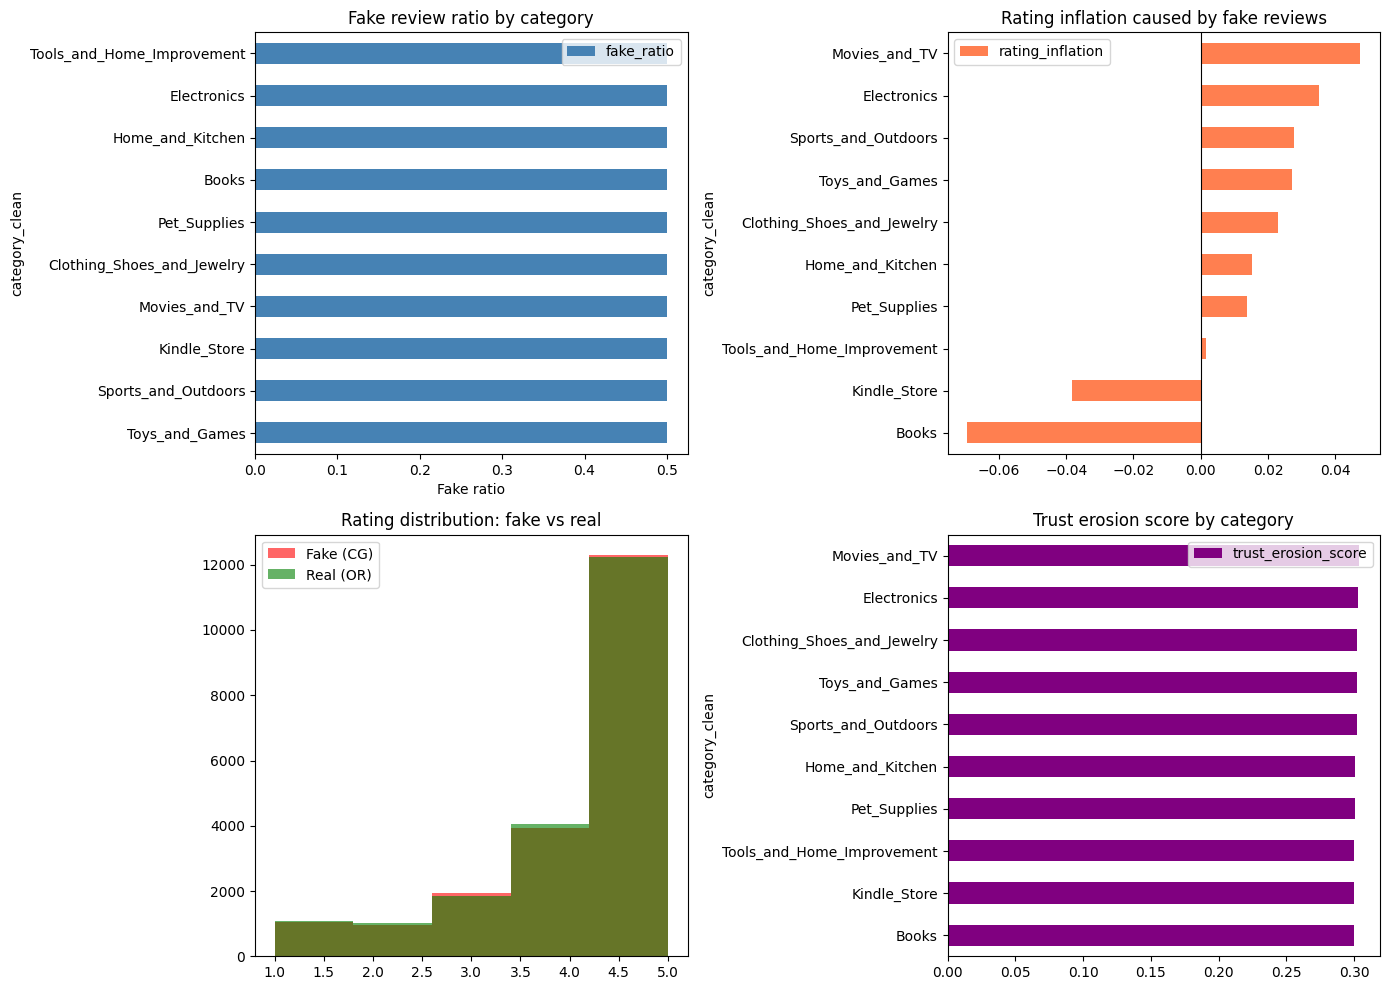

In [14]:
# ── Cell 7: Visualizations ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Fake ratio by category
cat_stats.sort_values('fake_ratio').plot.barh(
    x='category_clean', y='fake_ratio', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Fake review ratio by category')
axes[0,0].set_xlabel('Fake ratio')

# Plot 2: Rating inflation by category
cat_stats.sort_values('rating_inflation').plot.barh(
    x='category_clean', y='rating_inflation', ax=axes[0,1], color='coral')
axes[0,1].set_title('Rating inflation caused by fake reviews')
axes[0,1].axvline(0, color='black', linewidth=0.8)

# Plot 3: Rating distribution — fake vs real
axes[1,0].hist(fake_ratings, alpha=0.6, bins=5, label='Fake (CG)', color='red')
axes[1,0].hist(real_ratings, alpha=0.6, bins=5, label='Real (OR)', color='green')
axes[1,0].set_title('Rating distribution: fake vs real')
axes[1,0].legend()

# Plot 4: Trust erosion score
cat_stats.sort_values('trust_erosion_score').plot.barh(
    x='category_clean', y='trust_erosion_score', ax=axes[1,1], color='purple')
axes[1,1].set_title('Trust erosion score by category')

plt.tight_layout()
plt.savefig('purchase_impact_analysis.png', dpi=150)
plt.show()

In [15]:
# ── Cell 8: Final impact summary ─────────────────────────────────────────────
print("=" * 55)
print("FAKE REVIEW IMPACT ON PURCHASE BEHAVIOR — SUMMARY")
print("=" * 55)

for _, row in cat_stats.sort_values('trust_erosion_score', ascending=False).iterrows():
    print(f"\n{row['category_clean']}")
    print(f"  Fake ratio       : {row['fake_ratio']:.1%}")
    print(f"  Rating inflation : +{row['rating_inflation']:.2f} stars")
    print(f"  Trust erosion    : {row['trust_erosion_score']:.3f}")
    print(f"  Purchase rate    : {row['purchase_rate']:.1%}")

FAKE REVIEW IMPACT ON PURCHASE BEHAVIOR — SUMMARY

Movies_and_TV
  Fake ratio       : 50.0%
  Rating inflation : +0.05 stars
  Trust erosion    : 0.304
  Purchase rate    : 77.1%

Electronics
  Fake ratio       : 50.0%
  Rating inflation : +0.04 stars
  Trust erosion    : 0.303
  Purchase rate    : 78.3%

Toys_and_Games
  Fake ratio       : 50.0%
  Rating inflation : +0.03 stars
  Trust erosion    : 0.302
  Purchase rate    : 82.4%

Clothing_Shoes_and_Jewelry
  Fake ratio       : 50.0%
  Rating inflation : +0.02 stars
  Trust erosion    : 0.302
  Purchase rate    : 77.9%

Sports_and_Outdoors
  Fake ratio       : 50.0%
  Rating inflation : +0.03 stars
  Trust erosion    : 0.302
  Purchase rate    : 82.3%

Pet_Supplies
  Fake ratio       : 50.0%
  Rating inflation : +0.01 stars
  Trust erosion    : 0.301
  Purchase rate    : 78.1%

Home_and_Kitchen
  Fake ratio       : 50.0%
  Rating inflation : +0.02 stars
  Trust erosion    : 0.301
  Purchase rate    : 80.0%

Books
  Fake ratio       :

In [17]:
# ── Cell 9: Load saved model + get confidence scores ─────────────────────────
import pickle
from sklearn.preprocessing import StandardScaler

# Load the saved vectorizer and Naive Bayes model
tfidf = pickle.load(open('vectorizer.pkl', 'rb'))
mnb   = pickle.load(open('model.pkl', 'rb'))

# Re-load original data with category + rating intact
df_orig = pd.read_csv('fake reviews dataset.csv')
df_orig.rename(columns={'text_': 'text'}, inplace=True)
df_orig.drop_duplicates(inplace=True)
df_orig['category_clean'] = df_orig['category'].str.replace(r'_\d+$', '', regex=True)
df_orig['is_fake_ground_truth'] = (df_orig['label'] == 'CG').astype(int)
df_orig['purchase_proxy'] = (df_orig['rating'] >= 4).astype(int)
df_orig['sentiment'] = df_orig['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

In [18]:
# ── Cell 10: Generate model confidence scores ─────────────────────────────────
# Transform text using saved vectorizer
X_text = tfidf.transform(df_orig['text'])

# Fit the Multinomial Naive Bayes model
proba = mnb.predict_proba(X_text)

# predict_proba returns [P(CG/fake), P(OR/real)] for each review
proba = mnb.predict_proba(X_text)

df_orig['prob_fake']    = proba[:, 0]   # model's confidence it's fake (CG)
df_orig['prob_real']    = proba[:, 1]   # model's confidence it's real (OR)
df_orig['model_label']  = mnb.predict(X_text)  # 0=fake, 1=real

# Confidence = how sure the model is (closer to 1.0 = very confident)
df_orig['model_confidence'] = df_orig[['prob_fake', 'prob_real']].max(axis=1)

# Agreement flag: does model prediction match ground truth label?
df_orig['model_agrees'] = (df_orig['model_label'] == df_orig['is_fake_ground_truth']).astype(int)

df_orig[['text', 'label', 'model_label', 'prob_fake', 'prob_real', 'model_confidence']].head(10)

,text,label,model_label,prob_fake,prob_real,model_confidence
0,"Love this! Well made, sturdy, and very comfor...",CG,0,0.96,0.04,0.96
1,"love it, a great upgrade from the original. I...",CG,1,0.14,0.86,0.86
2,This pillow saved my back. I love the look and...,CG,0,0.76,0.24,0.76
3,"Missing information on how to use it, but it i...",CG,0,0.50,0.50,0.50
4,Very nice set. Good quality. We have had the s...,CG,0,0.92,0.08,0.92
5,I WANTED DIFFERENT FLAVORS BUT THEY ARE NOT.,CG,0,0.77,0.23,0.77
6,They are the perfect touch for me and the only...,CG,1,0.40,0.60,0.60
7,These done fit well and look great. I love th...,CG,0,0.74,0.26,0.74
8,"Great big numbers & easy to read, the only thi...",CG,0,0.82,0.18,0.82
9,My son loves this comforter and it is very wel...,CG,0,0.82,0.18,0.82


In [19]:
# ── Cell 11: Confidence-weighted impact analysis ──────────────────────────────
# Key idea: instead of binary is_fake (0/1), use prob_fake as a continuous
# "fakeness weight" — a review with prob_fake=0.95 contributes more to
# inflating ratings than one the model is unsure about (prob_fake=0.52)

# Weighted rating inflation per category
def weighted_inflation(group):
    fake_mask  = group['prob_fake'] > 0.5
    real_mask  = group['prob_real'] > 0.5

    # Confidence-weighted average rating for fake reviews
    fake_reviews = group[fake_mask]
    real_reviews = group[real_mask]

    if len(fake_reviews) == 0 or len(real_reviews) == 0:
        return np.nan

    weighted_fake_rating = np.average(
        fake_reviews['rating'],
        weights=fake_reviews['prob_fake']   # higher confidence = more weight
    )
    weighted_real_rating = np.average(
        real_reviews['rating'],
        weights=real_reviews['prob_real']
    )
    return weighted_fake_rating - weighted_real_rating

conf_stats = df_orig.groupby('category_clean').apply(
    lambda g: pd.Series({
        'total_reviews'            : len(g),
        'model_fake_count'         : (g['model_label'] == 0).sum(),
        'model_fake_ratio'         : (g['model_label'] == 0).mean(),
        'avg_confidence_on_fakes'  : g.loc[g['model_label'] == 0, 'model_confidence'].mean(),
        'avg_confidence_on_reals'  : g.loc[g['model_label'] == 1, 'model_confidence'].mean(),
        'weighted_rating_inflation': weighted_inflation(g),
        'purchase_rate'            : g['purchase_proxy'].mean(),
        'avg_sentiment_fake'       : g.loc[g['model_label'] == 0, 'sentiment'].mean(),
        'avg_sentiment_real'       : g.loc[g['model_label'] == 1, 'sentiment'].mean(),
    })
).reset_index()

# Confidence-adjusted trust erosion:
# penalizes categories where the model is VERY confident reviews are fake
conf_stats['conf_adjusted_trust_erosion'] = (
    conf_stats['model_fake_ratio'] * 0.5 +
    (conf_stats['weighted_rating_inflation'].clip(0) / 5) * 0.3 +
    conf_stats['avg_confidence_on_fakes'].fillna(0) * 0.2
).round(3)

print(conf_stats[[
    'category_clean', 'model_fake_ratio',
    'avg_confidence_on_fakes', 'weighted_rating_inflation',
    'conf_adjusted_trust_erosion'
]].sort_values('conf_adjusted_trust_erosion', ascending=False).to_string())

               category_clean  model_fake_ratio  avg_confidence_on_fakes  weighted_rating_inflation  conf_adjusted_trust_erosion
1  Clothing_Shoes_and_Jewelry          0.476735                 0.832274                   0.033919                        0.407
4                Kindle_Store          0.467640                 0.851000                  -0.001549                        0.404
3            Home_and_Kitchen          0.459566                 0.825601                   0.130403                        0.403
0                       Books          0.446326                 0.831015                   0.103130                        0.396
8  Tools_and_Home_Improvement          0.430016                 0.826942                   0.140091                        0.389
7         Sports_and_Outdoors          0.420132                 0.818383                   0.095903                        0.379
6                Pet_Supplies          0.403434                 0.819607                   0.0832

In [20]:
# ── Cell 12: Confidence vs purchase proxy correlation ────────────────────────
# Does higher model confidence in fakeness correlate with inflated purchase proxy?

# Bin reviews by model confidence into 5 buckets
df_orig['confidence_bucket'] = pd.cut(
    df_orig['prob_fake'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
)

bucket_stats = df_orig.groupby('confidence_bucket', observed=True).agg(
    avg_rating       = ('rating', 'mean'),
    purchase_rate    = ('purchase_proxy', 'mean'),
    avg_sentiment    = ('sentiment', 'mean'),
    count            = ('rating', 'count')
).reset_index()

print("\nAs model confidence in fakeness increases:")
print(bucket_stats.to_string(index=False))
# You should see: avg_rating rises as prob_fake approaches 1.0
# — direct evidence that high-confidence fake reviews inflate ratings
# — which in turn inflates the purchase_proxy


As model confidence in fakeness increases:
confidence_bucket  avg_rating  purchase_rate  avg_sentiment  count
            0-20%    4.269501       0.808833       0.252424   9102
           20-40%    4.312933       0.823337       0.283247   4902
           40-60%    4.314796       0.816286       0.291920   4028
           60-80%    4.304686       0.819726       0.293582   4887
          80-100%    4.298864       0.815697       0.287264   9951


In [21]:
# ── Cell 13: Disagreement analysis (where model ≠ ground truth) ───────────────
# These "borderline" reviews are the most interesting from a purchase impact POV
# — the model was unsure, meaning these reviews look authentic but were labeled fake

disagreements = df_orig[df_orig['model_agrees'] == 0].copy()

print(f"Total disagreements: {len(disagreements)} "
      f"({len(disagreements)/len(df_orig):.1%} of dataset)\n")

print("Disagreement breakdown by category:")
print(disagreements.groupby('category_clean')['model_confidence'].agg(['count', 'mean'])
      .rename(columns={'count': 'disagreement_count', 'mean': 'avg_confidence_at_disagreement'})
      .sort_values('disagreement_count', ascending=False))

# These reviews are dangerous from a purchase behavior standpoint:
# labeled fake by humans, but the model thinks they're real
# → most likely to deceive buyers
sneaky_fakes = df_orig[
    (df_orig['is_fake_ground_truth'] == 1) &  # actually fake
    (df_orig['model_label'] == 1)              # model thinks real
].copy()

print(f"\n'Sneaky fakes' (model fooled): {len(sneaky_fakes)}")
print(f"Avg rating of sneaky fakes: {sneaky_fakes['rating'].mean():.2f}")
print(f"Avg sentiment of sneaky fakes: {sneaky_fakes['sentiment'].mean():.3f}")
print(f"Purchase proxy rate: {sneaky_fakes['purchase_proxy'].mean():.1%}")
print("\nSample sneaky fakes:")
print(sneaky_fakes[['text', 'rating', 'prob_fake', 'sentiment']].head(5).to_string())

Total disagreements: 31782 (78.6% of dataset)

Disagreement breakdown by category:
                            disagreement_count  avg_confidence_at_disagreement
category_clean                                                                
Kindle_Store                              3882                        0.893738
Books                                     3429                        0.880673
Pet_Supplies                              3323                        0.878612
Home_and_Kitchen                          3264                        0.878359
Clothing_Shoes_and_Jewelry                3112                        0.871157
Sports_and_Outdoors                       3108                        0.876511
Electronics                               3103                        0.867684
Tools_and_Home_Improvement                3054                        0.880572
Toys_and_Games                            2786                        0.863982
Movies_and_TV                             2721  

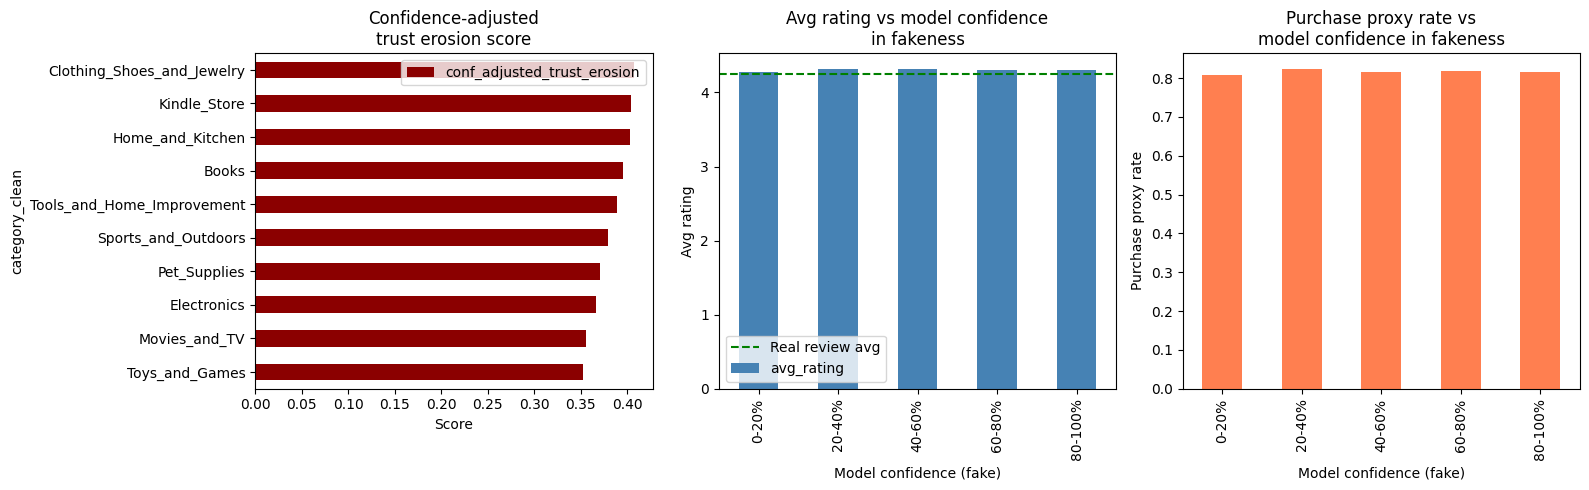

In [22]:
# ── Cell 14: Final confidence-aware visualization ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Confidence-adjusted trust erosion by category
conf_stats.sort_values('conf_adjusted_trust_erosion').plot.barh(
    x='category_clean', y='conf_adjusted_trust_erosion',
    ax=axes[0], color='darkred')
axes[0].set_title('Confidence-adjusted\ntrust erosion score')
axes[0].set_xlabel('Score')

# Plot 2: Avg rating across confidence buckets (fake reviews only)
bucket_stats.plot(
    x='confidence_bucket', y='avg_rating',
    kind='bar', ax=axes[1], color='steelblue', legend=False)
axes[1].set_title('Avg rating vs model confidence\nin fakeness')
axes[1].set_xlabel('Model confidence (fake)')
axes[1].set_ylabel('Avg rating')
axes[1].axhline(df_orig[df_orig['is_fake_ground_truth']==0]['rating'].mean(),
                color='green', linestyle='--', label='Real review avg')
axes[1].legend()

# Plot 3: Purchase rate across confidence buckets
bucket_stats.plot(
    x='confidence_bucket', y='purchase_rate',
    kind='bar', ax=axes[2], color='coral', legend=False)
axes[2].set_title('Purchase proxy rate vs\nmodel confidence in fakeness')
axes[2].set_xlabel('Model confidence (fake)')
axes[2].set_ylabel('Purchase proxy rate')

plt.tight_layout()
plt.savefig('confidence_purchase_impact.png', dpi=150)
plt.show()

In [23]:
# Run this ONCE to pre-compute category stats — saves time on app startup
import pickle
from textblob import TextBlob
import numpy as np
import pandas as pd
# Reload with category intact
df_full = pd.read_csv('fake reviews dataset.csv')
df_full.rename(columns={'text_': 'text'}, inplace=True)
df_full.drop_duplicates(inplace=True)
df_full['category_clean'] = df_full['category'].str.replace(r'_\d+$', '', regex=True).str.replace('_', ' ')
df_full['is_fake'] = (df_full['label'] == 'CG').astype(int)
df_full['purchase_proxy'] = (df_full['rating'] >= 4).astype(int)
df_full['sentiment'] = df_full['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Run model on full data to get confidence scores
X_full = tfidf.transform(df_full['text'])   # tfidf is already in memory from your notebook
proba  = mnb.predict_proba(X_full)          # mnb is already in memory

df_full['prob_fake']        = proba[:, 0]
df_full['prob_real']        = proba[:, 1]
df_full['model_label']      = mnb.predict(X_full)
df_full['model_confidence'] = df_full[['prob_fake','prob_real']].max(axis=1)
df_full['model_agrees']     = (df_full['model_label'] == df_full['is_fake']).astype(int)

# Save the enriched dataframe — app loads this instead of re-running everything
df_full.to_pickle('df_with_scores.pkl')
print("Saved! Shape:", df_full.shape)
print(df_full[['category_clean','prob_fake','model_label','sentiment']].head())

Saved! Shape: (40420, 13)
     category_clean  prob_fake  model_label  sentiment
0  Home and Kitchen       0.96            0   0.473750
1  Home and Kitchen       0.14            1   0.558333
2  Home and Kitchen       0.76            0   0.250000
3  Home and Kitchen       0.50            0   0.400000
4  Home and Kitchen       0.92            0   0.740000
